In [1]:
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
from data import load_pl

df = load_pl()
df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,2010-08-14,Aston Villa,West Ham,3.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,2010-08-14,Blackburn,Everton,1.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,2010-08-14,Bolton,Fulham,0.0,0.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,2010-08-14,Chelsea,West Brom,6.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,2010-08-14,Sunderland,Birmingham,2.0,2.0,D,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
seasons = df.groupby('Season').size()
seasons

Season
2010-11    380
2011-12    380
2012-13    380
2013-14    380
2014-15    380
2015-16    380
2016-17    380
2017-18    380
2018-19    380
2019-20    380
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
dtype: int64

### How do home-win, draw, and away-win rates change across Premier League seasons?

In [4]:
home_win = df.groupby("Season")["FTR"].apply(lambda r:(r=="H").mean())
home_win

Season
2010-11    0.471053
2011-12    0.450000
2012-13    0.436842
2013-14    0.471053
2014-15    0.452632
2015-16    0.413158
2016-17    0.492105
2017-18    0.455263
2018-19    0.476316
2019-20    0.452632
2020-21    0.378947
2021-22    0.428947
2022-23    0.484211
2023-24    0.460526
2024-25    0.407895
Name: FTR, dtype: float64

In [5]:
away_win = df.groupby("Season")["FTR"].apply(lambda r:(r=="A").mean())
away_win

Season
2010-11    0.236842
2011-12    0.305263
2012-13    0.278947
2013-14    0.323684
2014-15    0.302632
2015-16    0.305263
2016-17    0.286842
2017-18    0.284211
2018-19    0.336842
2019-20    0.305263
2020-21    0.402632
2021-22    0.339474
2022-23    0.286842
2023-24    0.323684
2024-25    0.347368
Name: FTR, dtype: float64

In [6]:
draw = df.groupby("Season")["FTR"].apply(lambda r:(r=="D").mean())
draw

Season
2010-11    0.292105
2011-12    0.244737
2012-13    0.284211
2013-14    0.205263
2014-15    0.244737
2015-16    0.281579
2016-17    0.221053
2017-18    0.260526
2018-19    0.186842
2019-20    0.242105
2020-21    0.218421
2021-22    0.231579
2022-23    0.228947
2023-24    0.215789
2024-25    0.244737
Name: FTR, dtype: float64

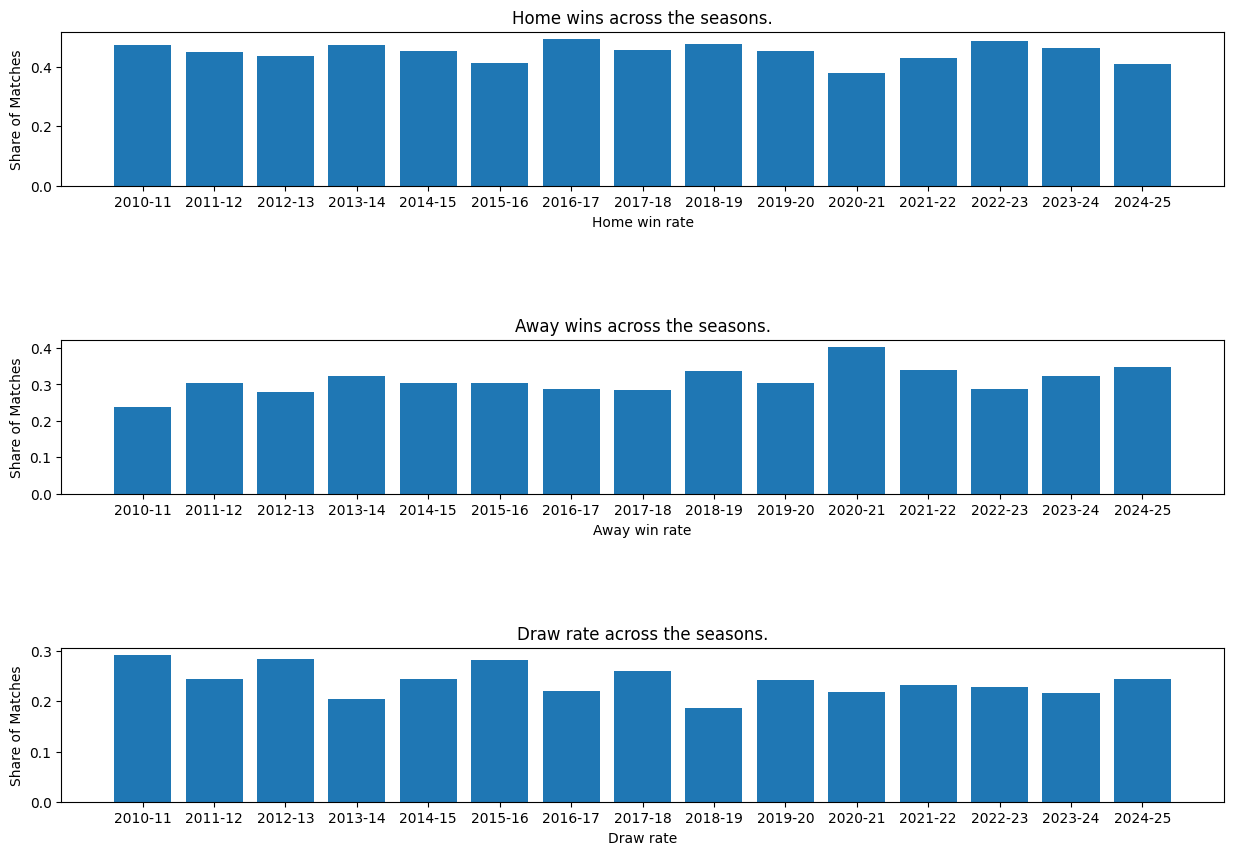

In [7]:
fig, ax = plt.subplots(3,1, figsize=(15,10))
ax[0].bar(home_win.index, home_win.values)
ax[0].set_xlabel("Home win rate")
ax[0].set_title("Home wins across the seasons.")
ax[0].set_ylabel("Share of Matches")

ax[1].bar(away_win.index, away_win.values)
ax[1].set_xlabel("Away win rate")
ax[1].set_title("Away wins across the seasons.")
ax[1].set_ylabel("Share of Matches")

ax[2].bar(draw.index, draw.values)
ax[2].set_xlabel("Draw rate")
ax[2].set_title("Draw rate across the seasons.")
ax[2].set_ylabel("Share of Matches")

plt.subplots_adjust(wspace=0.4, hspace=1)

Home wins are consistently more common than away wins and draws, indicating a clear home advantage. However, this advantage weakened noticeably in 2020–21 when matches were played without fans.

### What does the distribution of goals scored in a Premier League match look like?

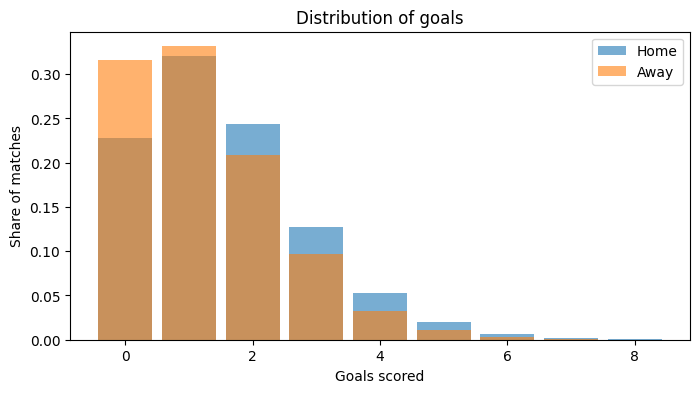

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, 9.5, 1)
ax.hist(df.FTHG, bins=bins, alpha=0.6, label="Home", density=True, rwidth=0.85)
ax.hist(df.FTAG, bins=bins, alpha=0.6, label="Away", density=True, rwidth=0.85)
ax.set_xlabel("Goals scored"); ax.set_ylabel("Share of matches")
ax.set_title("Distribution of goals")
ax.legend()

Home teams tend to score more than away teams, while away teams are more likely to be held scoreless.

### Are Premier League matches becoming more or less high-scoring over time?

<Axes: xlabel='Season'>

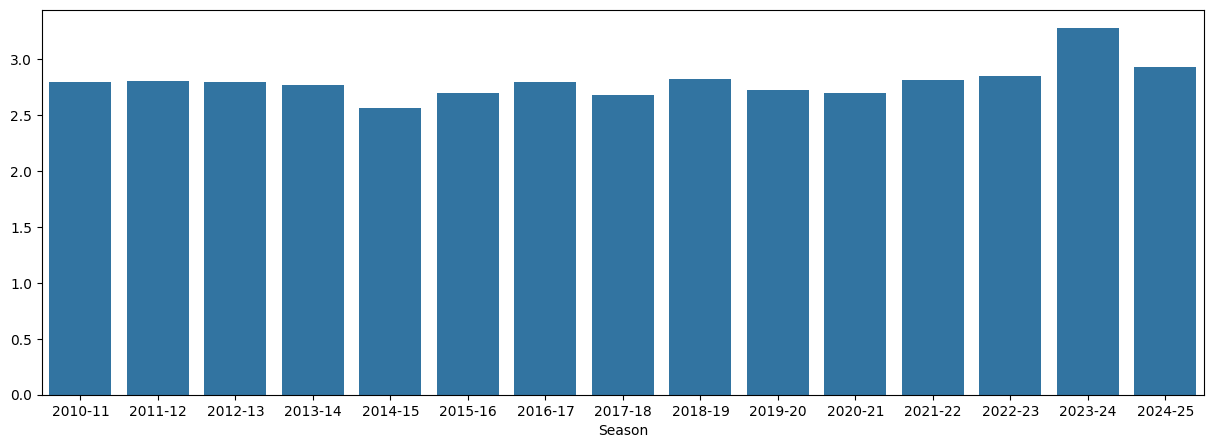

In [30]:
total_goals = df.groupby("Season").apply(
    lambda group: (group["FTHG"] + group["FTAG"]).mean()
)
total_goals

plt.figure(figsize=(15,5))
sns.barplot(x=total_goals.index,y=total_goals.values)

The average number of goals per match is above 2.5 across the seasons analyzed. However, the 2023–24 season stands out, with the average exceeding 3 goals per game.

### How have the average number of yellow and red cards per match changed across Premier League seasons?

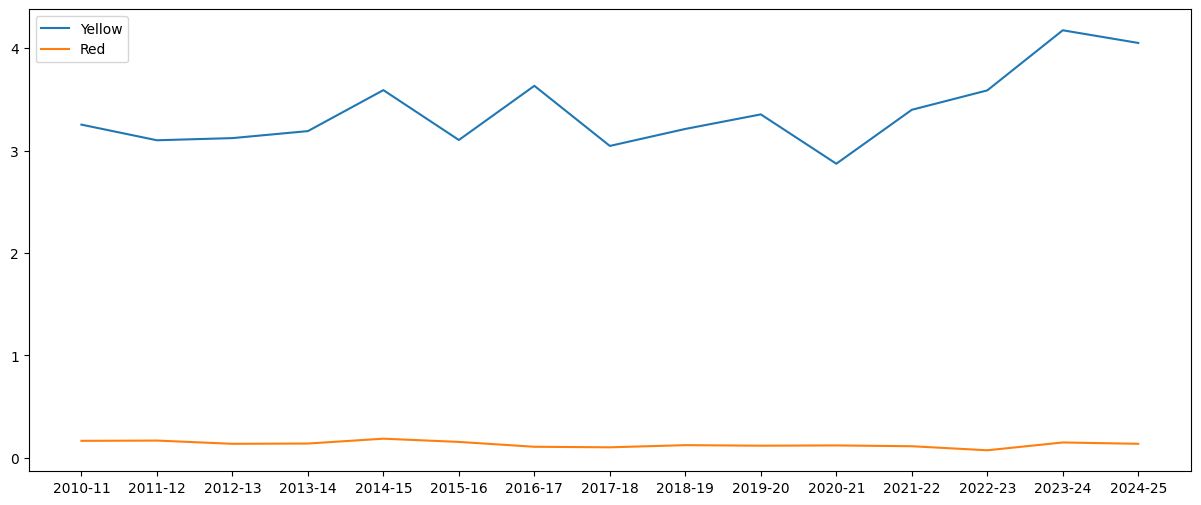

In [17]:
cards = pd.DataFrame({
    "Season":df.Season,
    "Yellow" : df.HY+df.AY,
    "Red" : df.HR + df.AR,
})
avg_card = cards.groupby("Season").agg(yellow = ("Yellow","mean"), red = ("Red","mean"))

plt.figure(figsize=(15,6))
plt.plot(avg_card.index, avg_card.values)
plt.legend(["Yellow", "Red"])
plt.show()


Yellow cards have fluctuated across seasons, while red cards have remained relatively low and stable throughout the period.

### How well calibrated are bookmaker probabilities?

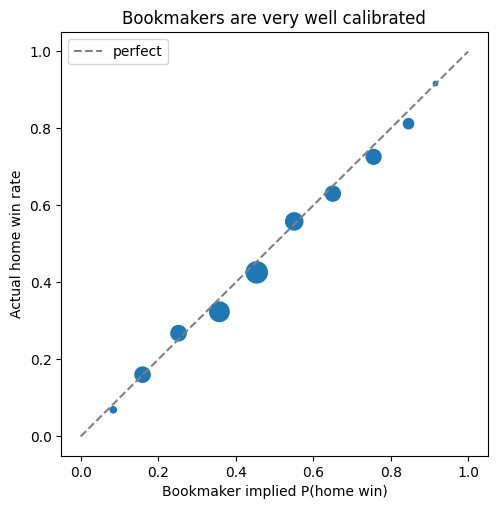

In [31]:
pl = df.copy()
d = pl.dropna(subset=["B365H"]).copy()
d["p_imp"] = 1 / d.B365H
d["home_win"] = (d.FTR == "H").astype(int)
d["bin"] = pd.cut(d.p_imp, bins=np.linspace(0, 1, 11))
cal = d.groupby("bin", observed=True).agg(p_imp=("p_imp", "mean"), actual=("home_win", "mean"), n=("home_win", "size"))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
ax.scatter(cal.p_imp, cal.actual, s=cal.n / 5)
ax.set(xlabel="Bookmaker implied P(home win)", ylabel="Actual home win rate",
       title="Bookmakers are very well calibrated")
ax.legend()

Points on the diagonal mean that when the bookmaker says 60%, the home team wins about 60% of the time.